# Newton's Method for Two Variables

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture that closes Week 3:
**Newton's method in many variables** (Week 3 — Optimization in Neural Networks and Newton's
Method).

This notebook explains:

- how the one-variable Newton step generalizes using the **gradient** and the **Hessian**
- the update $\;\mathbf{x}_{k+1} = \mathbf{x}_k - H^{-1}\,\nabla f$
- why the **order** matters ($H^{-1}$ multiplies the gradient on the right)
- a worked example converging from $(4,4)$ to the minimum $(0,0)$ in a handful of steps
- a robust implementation (solve, don't invert) and a visualization of the path

This notebook follows the repository `GUIDELINES.md` template and concludes the Week 3
material, building on *The Hessian* and *Hessians and Concavity*.

## 1. From one variable to many

The one-variable Newton optimization step was

$$
x_{k+1} = x_k - \frac{f'(x_k)}{f''(x_k)}.
$$

Rewrite the division as multiplication by the **inverse** of the second derivative:

$$
x_{k+1} = x_k - \big[f''(x_k)\big]^{-1} f'(x_k).
$$

In two variables the iterate is a **vector** $\mathbf{x}_k = (x_k, y_k)$, and:

- the first derivative $f'$ becomes the **gradient** $\nabla f$ (a vector),
- the second derivative $f''$ becomes the **Hessian** $H$ (a matrix),
- "dividing by $f''$" becomes multiplying by the **inverse Hessian** $H^{-1}$.

$$
\boxed{\;\begin{bmatrix} x_{k+1} \\ y_{k+1} \end{bmatrix}
= \begin{bmatrix} x_{k} \\ y_{k} \end{bmatrix} - H^{-1}\,\nabla f.\;}
$$

This same formula works for $n$ variables: an $n$-vector minus an $n\times n$ matrix
($H^{-1}$) times an $n$-vector ($\nabla f$).

## 2. The order matters

It is tempting to write $\nabla f \cdot H^{-1}$, but that is **wrong**. The Hessian is
$2\times 2$ and the gradient is $2\times 1$; you can only multiply the matrix on the **left**
of the column vector:

$$
\underbrace{H^{-1}}_{2\times 2}\;\underbrace{\nabla f}_{2\times 1} \;=\; \underbrace{\text{a }2\times1\text{ vector}}_{\checkmark}
\qquad\text{not}\qquad
\underbrace{\nabla f}_{2\times 1}\,\underbrace{H^{-1}}_{2\times 2}\;\;(\text{✗ shapes don't match}).
$$

## 3. The example

> *"Here is a function that is concave up, and we're going to find the minimum... start at
> the point $(4,4)$ ... it takes eight steps to get this close ... really, really close to
> $(0,0)$."*

The audio describes the function only on the slide, so we use a **representative**
concave-up function with a minimum at $(0,0)$ and the same behaviour (Newton reaches the
minimum from $(4,4)$ in about eight steps):

$$
f(x,y) = \cosh(x) + \cosh(y),
$$

with gradient and Hessian

$$
\nabla f = \begin{bmatrix} \sinh x \\ \sinh y \end{bmatrix},\qquad
H = \begin{bmatrix} \cosh x & 0 \\ 0 & \cosh y \end{bmatrix}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x, y = sp.symbols('x y')
f = sp.cosh(x) + sp.cosh(y)

grad = sp.Matrix([sp.diff(f, x), sp.diff(f, y)])
H = sp.hessian(f, (x, y))
print("gradient ∇f ="); sp.pprint(grad.T)
print("Hessian H ="); sp.pprint(H)

# numeric callables
grad_n = sp.lambdify((x, y), grad, 'numpy')
H_n    = sp.lambdify((x, y), H, 'numpy')

gradient ∇f =
[sinh(x)  sinh(y)]
Hessian H =
⎡cosh(x)     0   ⎤
⎢                ⎥
⎣   0     cosh(y)⎦


## 4. Running Newton's method from $(4, 4)$

Each step solves $H\,\mathbf{d} = \nabla f$ for the update $\mathbf{d}$ and sets
$\mathbf{x} \leftarrow \mathbf{x} - \mathbf{d}$. (Solving the linear system is more stable
than explicitly inverting $H$ — mathematically it is $\mathbf{d} = H^{-1}\nabla f$.)

In [2]:
def newton_2d(grad_n, H_n, start, n_iter=8):
    p = np.array(start, dtype=float)
    history = [p.copy()]
    for _ in range(n_iter):
        g = np.array(grad_n(p[0], p[1]), dtype=float).reshape(2)
        Hm = np.array(H_n(p[0], p[1]), dtype=float).reshape(2, 2)
        d = np.linalg.solve(Hm, g)        # d = H^{-1} ∇f
        p = p - d
        history.append(p.copy())
    return np.array(history)

hist = newton_2d(grad_n, H_n, start=(4.0, 4.0), n_iter=8)

print(f"{'k':>2} | {'x_k':>14} | {'y_k':>14}")
print("-" * 38)
for k, (xk, yk) in enumerate(hist):
    print(f"{k:>2} | {xk:>14.6e} | {yk:>14.6e}")
print("\n-> converges to (0, 0), the minimum, in ~8 steps (matching the lecture).")

 k |            x_k |            y_k
--------------------------------------
 0 |   4.000000e+00 |   4.000000e+00
 1 |   3.000671e+00 |   3.000671e+00
 2 |   2.005609e+00 |   2.005609e+00
 3 |   1.041188e+00 |   1.041188e+00
 4 |   2.628310e-01 |   2.628310e-01
 5 |   5.889448e-03 |   5.889448e-03
 6 |   6.809208e-08 |   6.809208e-08
 7 |   9.264423e-23 |   9.264423e-23
 8 |   0.000000e+00 |   0.000000e+00

-> converges to (0, 0), the minimum, in ~8 steps (matching the lecture).


## 5. Visualizing the path

The contours of $f$ with the Newton iterates marching from $(4,4)$ to the minimum at the
center.

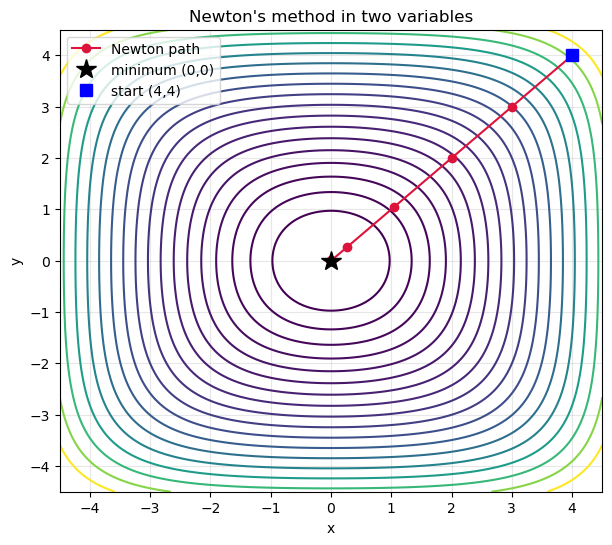

In [3]:
gx = np.linspace(-4.5, 4.5, 200); gy = np.linspace(-4.5, 4.5, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = np.cosh(GX) + np.cosh(GY)

plt.figure(figsize=(7, 6))
cs = plt.contour(GX, GY, GZ, levels=np.logspace(0.4, 1.8, 18), cmap="viridis")
plt.plot(hist[:, 0], hist[:, 1], "o-", color="crimson", markersize=6, label="Newton path")
plt.plot(0, 0, "k*", markersize=15, label="minimum (0,0)")
plt.plot(4, 4, "bs", markersize=8, label="start (4,4)")
plt.title("Newton's method in two variables")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 6. A quadratic converges in one step

For a **quadratic** function the Hessian is constant and Newton's method jumps straight to
the minimum in a single step — the multivariable version of "exact for parabolas".

In [4]:
q = 2*x**2 + 3*y**2 - x*y          # the convex bowl from the Hessian lecture
gq = sp.lambdify((x, y), sp.Matrix([sp.diff(q, x), sp.diff(q, y)]), 'numpy')
Hq = sp.lambdify((x, y), sp.hessian(q, (x, y)), 'numpy')

hq = newton_2d(gq, Hq, start=(4.0, 4.0), n_iter=2)
print("quadratic iterates:")
for k, (xk, yk) in enumerate(hq):
    print(f"  step {k}: ({xk:.3e}, {yk:.3e})")
print("-> reaches the minimum (0,0) in a single Newton step.")

quadratic iterates:
  step 0: (4.000e+00, 4.000e+00)
  step 1: (0.000e+00, 0.000e+00)
  step 2: (0.000e+00, 0.000e+00)
-> reaches the minimum (0,0) in a single Newton step.


## 7. Exercises

### Basic
1. Write Newton's update for two variables.
2. Why must $H^{-1}$ multiply the gradient on the left, not the right?

### Intermediate
3. Run Newton's method on $f(x,y) = \cosh(x) + \cosh(y)$ from a different start, e.g.
   $(2, -3)$. Does it still reach $(0,0)$?
4. Confirm that the convex quadratic $2x^2 + 3y^2 - xy$ is minimized in one Newton step.

### Advanced
5. Apply Newton's method to $f(x,y) = x^2 + y^2 + \tfrac14(x^4 + y^4)$ from $(3,3)$ and
   report the number of steps to reach $\|\nabla f\| < 10^{-8}$.
6. Why is solving $H\mathbf{d} = \nabla f$ preferable to computing $H^{-1}$ explicitly?

## 8. Solutions / Checks

In [5]:
# 3. different start
h3 = newton_2d(grad_n, H_n, start=(2.0, -3.0), n_iter=10)
print(f"3. from (2,-3): final = ({h3[-1,0]:.2e}, {h3[-1,1]:.2e}) -> reaches (0,0)")

# 4. quadratic in one step (already shown)
print(f"4. quadratic: after 1 step = ({hq[1,0]:.2e}, {hq[1,1]:.2e}) -> (0,0)")

# 5. quartic-plus-quadratic
f5 = x**2 + y**2 + (x**4 + y**4)/4
g5 = sp.lambdify((x, y), sp.Matrix([sp.diff(f5, x), sp.diff(f5, y)]), 'numpy')
H5 = sp.lambdify((x, y), sp.hessian(f5, (x, y)), 'numpy')
p = np.array([3.0, 3.0]); steps = 0
while True:
    g = np.array(g5(p[0], p[1]), float).reshape(2)
    if np.linalg.norm(g) < 1e-8: break
    p = p - np.linalg.solve(np.array(H5(p[0], p[1]), float).reshape(2,2), g)
    steps += 1
print(f"5. converged in {steps} steps to ({p[0]:.2e}, {p[1]:.2e})")

print("1. [x,y]_{k+1} = [x,y]_k - H^{-1} ∇f")
print("2. H^{-1} is 2x2 and ∇f is 2x1; only H^{-1}·∇f (matrix·vector) has valid shapes.")
print("6. Solving the system is faster and numerically more stable than forming the inverse.")

3. from (2,-3): final = (0.00e+00, 0.00e+00) -> reaches (0,0)
4. quadratic: after 1 step = (0.00e+00, 0.00e+00) -> (0,0)
5. converged in 6 steps to (1.36e-11, 1.36e-11)
1. [x,y]_{k+1} = [x,y]_k - H^{-1} ∇f
2. H^{-1} is 2x2 and ∇f is 2x1; only H^{-1}·∇f (matrix·vector) has valid shapes.
6. Solving the system is faster and numerically more stable than forming the inverse.


## 9. Conclusion

- Newton's method extends to many variables by replacing the derivative with the
  **gradient** and the second derivative with the **Hessian**:

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - H^{-1}\,\nabla f .
$$

- **Order matters**: the inverse Hessian multiplies the gradient on the left.
- It converges very fast — from $(4,4)$ to the minimum $(0,0)$ in about eight steps, and in
  a **single** step for a quadratic.
- The cost is computing and inverting (or solving with) the Hessian each step — cheap in 2D,
  but expensive for the millions of parameters in large neural networks, which is why
  **gradient descent** remains the workhorse there.

This concludes the Week 3 material: from perceptrons and backpropagation to Newton's method
and the Hessian — the calculus behind training and optimizing machine-learning models.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (3).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on **Newton's method for two variables**. Key spoken points,
lightly cleaned (the specific example function was shown on-screen, not stated in the
audio; a representative concave-up function is used here):

> Apply Newton's method to optimize functions of many variables — the Hessian appears. The
> one-variable step $x_{k+1} = x_k - f'(x_k)/f''(x_k)$ can be written as $x_k -
> [f''(x_k)]^{-1} f'(x_k)$. In two variables the iterate is $(x_k, y_k)$; the first
> derivative becomes the gradient and the second derivative becomes the Hessian, so the
> step is $[x,y]_{k+1} = [x,y]_k - H^{-1}\nabla f$, which generalizes to $n$ variables.
> Order is crucial: you multiply the inverse Hessian (2×2) on the left of the gradient
> (2×1), not the right. For a concave-up example starting at $(4,4)$, the gradient and
> Hessian give the next point $(2.58, 2.62)$, then $(1.59, 1.67)$, and after eight steps you
> reach about $(4.15\times10^{-17}, -2.05\times10^{-17})$ — essentially $(0,0)$, the
> minimum. Like the one-variable case, Newton's method in two variables is very fast.